In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import cv2
import numpy as np

In [2]:
image = Image.open('Optical/USAF1951.png')

image = image.convert('L')
image = Image.fromarray(np.array(image)[50:570,60:580])
image.show()
image = image.resize((282, 282)) # measured image size
print(image.size)
image.save('Optical/USAF1951_gray.png')

image_line = image.copy()
draw = ImageDraw.Draw(image_line)

x1, y1, x2, y2 = 75, 70, 129, 70
draw.line((x1, y1, x2, y2), fill='red', width=3)

image_line.save('Optical/USAF1951_line.png')

(282, 282)


In [3]:
image_np = np.array(image)
print(image_np.shape)
roi_optical = image_np[y1, x1:x2]

# plt.plot(roi_optical)

(282, 282)


In [4]:
def get_roi(image_path):
    image = Image.open(image_path)
    
    x1, y1, x2, y2 = 75, 70, 129, 70
    if 'zssr' in image_path:
        x1, y1, x2, y2 = [i * 2 for i in (x1, y1, x2, y2)]

    image_np = np.array(image)
    roi = image_np[y1, x1:x2]

    return roi

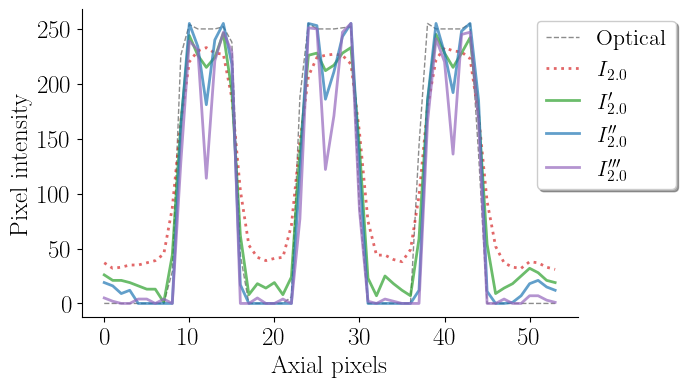

In [8]:
plt.rcParams['text.usetex'] = True # This works only at Ubuntu machine that has LaTex on it (sudo apt-get update; sudo apt-get install texlive-full)
plt.rcParams['font.family'] = 'Times New Roman'

roi_org = get_roi('TotalExp/original/resol1951_2_e_2.0THz.png')
roi_o2o = get_roi('TotalExp/o2o/2.0/resol1951_2_e_2.0THz(1.5to2.0).png')
roi_recur = get_roi('TotalExp/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0)).png')
roi_rerecur = get_roi('TotalExp/recurrent/resol1951_2_e_2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0))(2.0THz(1.5to2.0)to2.0THz(1.5to2.0)(2.0THzto2.0THz(1.5to2.0))).png')
# roi_zssr = get_roi('TotalExp/recurrent_zssr/resol1951_2_e_2.0THz(1.5to2.0)_zssr.png')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18

plt.figure(figsize=(6.4, 4))
plt.plot(roi_optical, '--', label='Optical', color='gray', linewidth=1, alpha=0.9)
plt.plot(roi_org, ':', label=r'$I_{2.0}$', color='tab:red', linewidth=2, alpha=0.7)
plt.plot(roi_o2o, label=r"$I_{2.0}'$", color='tab:green', linewidth=2, alpha=0.7)
plt.plot(roi_recur, label=r"$I_{2.0}''$", color='tab:blue', linewidth=2, alpha=0.7)
plt.plot(roi_rerecur, label=r"$I_{2.0}'''$", color='tab:purple', linewidth=2, alpha=0.7)
# plt.ylim(0, 270)
plt.legend(loc='upper right', ncol=1, bbox_to_anchor=(1.22, 1), prop={'size': 16}, shadow=True, fancybox=True, frameon=True, handlelength=1.5)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Axial pixels')
plt.ylabel('Pixel intensity')
plt.savefig('axial_graph_2.0.svg')
plt.show()

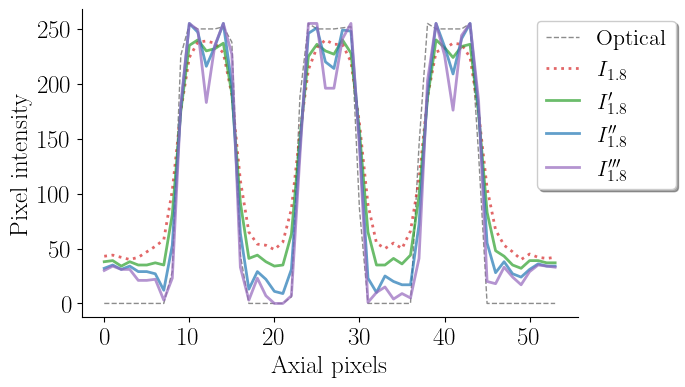

In [9]:
roi_org = get_roi('TotalExp/original/resol1951_2_e_1.8THz.png')
roi_o2o = get_roi('TotalExp/o2o/1.8/resol1951_2_e_1.8THz(1.5to1.8).png')
roi_recur = get_roi('TotalExp/recurrent/resol1951_2_e_1.8THz(1.5to1.8)(1.8THzto1.8THz(1.5to1.8)).png')
roi_rerecur = get_roi('TotalExp/recurrent/resol1951_2_e_1.8THz(1.5to1.8)(1.8THzto1.8THz(1.5to1.8))(1.8THz(1.5to1.8)to1.8THz(1.5to1.8)(1.8THzto1.8THz(1.5to1.8))).png')
# plt.legend(loc='upper center', ncol=1, bbox_to_anchor=(1.2, 0.65))

plt.figure(figsize=(6.4, 4))
plt.plot(roi_optical, '--', label='Optical', color='gray', linewidth=1, alpha=0.9)
plt.plot(roi_org, ':', label=r'$I_{1.8}$', color='tab:red', linewidth=2, alpha=0.7)
plt.plot(roi_o2o, label=r"$I_{1.8}'$", linewidth=2, color='tab:green', alpha=0.7)
plt.plot(roi_recur, label=r"$I_{1.8}''$", linewidth=2, alpha=0.7)
plt.plot(roi_rerecur, label=r"$I_{1.8}'''$", color='tab:purple', linewidth=2, alpha=0.7)

# 범례 위치 조정
plt.legend(loc='upper right', ncol=1, bbox_to_anchor=(1.22, 1), prop={'size': 16}, shadow=True, fancybox=True, frameon=True, handlelength=1.5)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Axial pixels')
plt.ylabel('Pixel intensity')
plt.savefig('axial_graph_1.8.svg')
plt.show()